# Step 1 : Environment Setup and Library Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')
dataset_base_path = "./drive/MyDrive/Brain_Tumor_Classification/dataset_extracted/Brain-Tumor-Classification-DataSet-master"
train_dir = os.path.join(dataset_base_path, 'Training')
val_dir = os.path.join(dataset_base_path, 'Testing')

print("✅ Base path established. Ready for ResNet18 Layered Tuning.")

Mounted at /content/drive
✅ Base path established. Ready for ResNet18 Layered Tuning.


# Step 2 : Safe Medical Data Augmentation (No Information Erasing)

In [ ]:
# Removing RandomErasing to preserve the delicate borders of Glioma tumors
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = ImageFolder(root=val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Safe DataLoaders re-established. Classes: {train_dataset.classes}")

✅ Safe DataLoaders re-established. Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


# Step 3 : Initializing ResNet18 Backbone

In [ ]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Ensure all parameters are unfrozen, but they will be updated with different speeds
for param in model.parameters():
    param.requires_grad = True

print(f" ResNet18 loaded on {device.type.upper()}. Parameters unlocked for differential learning.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


🔓 ResNet18 loaded on CUDA. Parameters unlocked for differential learning.


# Step 4 : Loss Weighting & Discriminative (Layered) Learning Rates

In [ ]:
# Keep the 2.5 bias on Class 0 to enforce hard-case learning
weights = torch.tensor([2.5, 1.0, 1.0, 1.0], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Grouping parameters for Layered Learning Rates
optimizer = torch.optim.Adam([
    {'params': model.conv1.parameters(), 'lr': 1e-6},
    {'params': model.bn1.parameters(), 'lr': 1e-6},
    {'params': model.layer1.parameters(), 'lr': 1e-6},  # Low layers: Preserve ImageNet edges
    {'params': model.layer2.parameters(), 'lr': 1e-5},  # Mid layers: Adapt slowly
    {'params': model.layer3.parameters(), 'lr': 1e-5},  # High layers: Adapt to MRI structures
    {'params': model.layer4.parameters(), 'lr': 5e-5},  # Deep features: Active tumor analysis
    {'params': model.fc.parameters(), 'lr': 1e-4}       # Classifier: Fast adaptation to 4 classes
], weight_decay=0.0002)

print("Advanced Layered Optimizer configured successfully.")

🎯 Advanced Layered Optimizer configured successfully.


# Step 5 : Secure Training Loop with Validation Checkpointing and Auto-Resume

In [ ]:
epochs = 15
start_epoch = 0
best_val_acc = 0.0

checkpoint_dir = "./drive/MyDrive/Brain_Tumor_Classification"
checkpoint_path_day7_v2 = os.path.join(checkpoint_dir, 'best_brain_tumor_model_day7_v2.pth')

# Safe Resume Check
if os.path.exists(checkpoint_path_day7_v2):
    print("Found existing Day 7 V2 checkpoint! Resuming training...")
    checkpoint = torch.load(checkpoint_path_day7_v2, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    best_val_acc = checkpoint['accuracy']
    print(f"▶️ Resuming from Epoch {start_epoch + 1} | Current Record Val Acc: {best_val_acc:.2f}%")
else:
    print("No checkpoint found. Starting fresh Day 7 V2 optimization.")

scaler = torch.amp.GradScaler('cuda')

for epoch in range(start_epoch, epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = (correct_train / total_train) * 100

    # --- VALIDATION / TESTING PHASE ---
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = (val_correct / val_total) * 100

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || Val Acc: {val_acc:.2f}%")

    # Secure Checkpoint Save
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': val_acc
        }, checkpoint_path_day7_v2)
        print(f"--> 🔥 New Record! Saved Step 7 V2 Checkpoint with Val Acc: {val_acc:.2f}%")

    torch.cuda.empty_cache()

print(f"\n Training Complete! Ultimate Step 7 V2 Accuracy: {best_val_acc:.2f}%")

⏳ Found existing Day 7 V2 checkpoint! Resuming training...
▶️ Resuming from Epoch 8 | Current Record Val Acc: 78.93%
Epoch [8/15] | Train Loss: 0.0482 | Train Acc: 98.33% || Val Acc: 80.46%
--> 🔥 New Record! Saved Day 7 V2 Checkpoint with Val Acc: 80.46%
Epoch [9/15] | Train Loss: 0.0449 | Train Acc: 98.47% || Val Acc: 78.43%
Epoch [10/15] | Train Loss: 0.0457 | Train Acc: 98.68% || Val Acc: 76.90%
Epoch [11/15] | Train Loss: 0.0432 | Train Acc: 98.75% || Val Acc: 78.68%
Epoch [12/15] | Train Loss: 0.0407 | Train Acc: 98.57% || Val Acc: 77.16%
Epoch [13/15] | Train Loss: 0.0280 | Train Acc: 98.89% || Val Acc: 78.68%
Epoch [14/15] | Train Loss: 0.0338 | Train Acc: 98.82% || Val Acc: 76.90%
Epoch [15/15] | Train Loss: 0.0384 | Train Acc: 98.68% || Val Acc: 76.14%

🎯 Training Complete! Ultimate Day 7 V2 Accuracy: 80.46%


# Step 6 : Evaluation and Confusion Matrix Generation

Loaded best Day 7 V2 model (Accuracy: 80.46%)


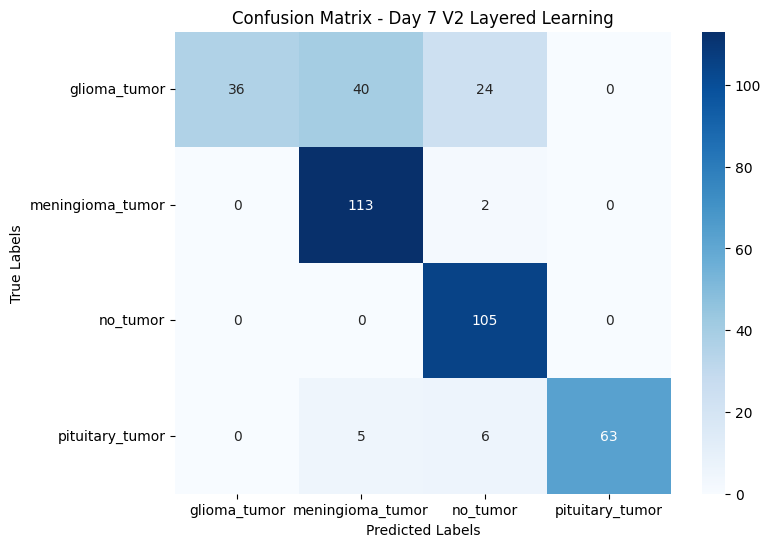

                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.36      0.53       100
meningioma_tumor       0.72      0.98      0.83       115
        no_tumor       0.77      1.00      0.87       105
 pituitary_tumor       1.00      0.85      0.92        74

        accuracy                           0.80       394
       macro avg       0.87      0.80      0.79       394
    weighted avg       0.85      0.80      0.78       394



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

if os.path.exists(checkpoint_path_day7_v2):
    checkpoint = torch.load(checkpoint_path_day7_v2, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best Step 7 V2 model (Accuracy: {checkpoint['accuracy']:.2f}%)")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_dataset.classes, yticklabels=val_dataset.classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Step 7 V2 Layered Learning')
plt.show()

print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))